# 06 - Embeddings & Topic Modeling

**Goal**: Convert job descriptions into dense vector representations (embeddings)
and discover natural job clusters using topic modeling.

**Learning concepts**: Sentence embeddings, vector similarity, FAISS indexing,
BERTopic (UMAP + HDBSCAN + c-TF-IDF), dimensionality reduction.

**Why this matters**:
- Embeddings are the foundation for **RAG** (Phase 4) — searching similar jobs by meaning
- Topic modeling reveals natural job clusters without manual labels
- Both are core techniques for any NLP-heavy data science project

---

In [1]:
print(f"Importing libraries and modules...")

FORCE_RECOMPUTE = False  # Set to True to recompute embeddings + retrain BERTopic from scratch

# ── Windows + Anaconda DLL fix ────────────────────────────────────────────────
# NumPy (and several other packages) load OpenMP/MKL DLLs that conflict with
# PyTorch's bundled libomp.dll on Windows.  Importing torch FIRST (before numpy,
# pandas, etc.) guarantees its DLLs are initialised in the right order.
# KMP_DUPLICATE_LIB_OK silences the "duplicate OpenMP runtime" abort that can
# otherwise crash the kernel on Anaconda-based environments.
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import torch  # noqa: E402 – must come before numpy/pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from talentlens.config import (
    POSTINGS_NLP_PARQUET, EMBEDDINGS_NPY, EMBEDDING_JOB_IDS_NPY,
    EMBEDDING_MODEL_NAME, PROCESSED_DIR, MODELS_DIR, BERTOPIC_MODEL_DIR,
)
from talentlens.features import generate_embeddings
from talentlens.plots import save_fig

pd.set_option('display.max_columns', None)
%matplotlib inline

print(f"[SUCCESS] Libraries and modules imported.")

Importing libraries and modules...
[SUCCESS] Libraries and modules imported.


In [2]:
# Load the NLP-preprocessed dataset
if not POSTINGS_NLP_PARQUET.exists():
    raise FileNotFoundError(
        "postings_nlp.parquet not found! "
        "Run notebook 04-mp-nlp-text-preprocessing.ipynb first."
    )

df = pd.read_parquet(POSTINGS_NLP_PARQUET)
print(f"Loaded {len(df):,} postings")

Loaded 123,842 postings


## 1. What Are Embeddings?

An **embedding** converts text into a fixed-size vector of numbers (e.g., 384 floats).

```
"Senior Python Developer"  →  [0.12, -0.34, 0.56, ..., 0.08]  (384 numbers)
"Lead Backend Engineer"    →  [0.11, -0.31, 0.58, ..., 0.09]  (384 numbers, similar!)
"Pastry Chef"              →  [-0.45, 0.22, -0.10, ..., 0.67] (384 numbers, very different)
```

**Key property**: Similar texts get similar vectors. We can measure similarity with
**cosine similarity** — the angle between two vectors.

**Why not TF-IDF?** TF-IDF creates sparse vectors based on exact word matches.
Embeddings capture **meaning**: "Python developer" and "software engineer" have similar
embeddings even though they share no words.

**Model**: `all-MiniLM-L6-v2` — a compact, fast model that produces 384-dimensional embeddings.
It's free, runs on CPU, and is the go-to for most embedding tasks.

---

## 2. Generate Embeddings

We'll embed the **cleaned descriptions** (not the lemmatized ones).
Why? The sentence-transformer model was trained on natural text, not lemmatized fragments.
It handles its own tokenization internally.

**Performance note**: 123K texts × 384 dimensions takes ~15-30 minutes on CPU.
The progress bar will show you exactly where you are.

In [3]:
# Check if embeddings already exist (skip if re-running)
if not FORCE_RECOMPUTE and EMBEDDINGS_NPY.exists() and EMBEDDING_JOB_IDS_NPY.exists():
    print("Embeddings already exist! Loading from disk...")
    embeddings = np.load(EMBEDDINGS_NPY)
    job_ids = np.load(EMBEDDING_JOB_IDS_NPY)
    print(f"Loaded embeddings: {embeddings.shape}")
else:
    # Generate fresh embeddings
    texts = df['desc_clean'].fillna('').tolist()
    
    start_time = time.time()
    embeddings = generate_embeddings(texts, model_name=EMBEDDING_MODEL_NAME, batch_size=256)
    elapsed = time.time() - start_time
    
    print(f"\nGenerated {embeddings.shape[0]:,} embeddings in {elapsed/60:.1f} minutes")
    print(f"Shape: {embeddings.shape} | Dtype: {embeddings.dtype}")
    print(f"Memory: {embeddings.nbytes / 1e6:.1f} MB")
    
    # Save to disk
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    np.save(EMBEDDINGS_NPY, embeddings)
    np.save(EMBEDDING_JOB_IDS_NPY, df['job_id'].values)
    print(f"\nSaved embeddings to {EMBEDDINGS_NPY}")
    print(f"Saved job IDs to {EMBEDDING_JOB_IDS_NPY}")
    
    job_ids = df['job_id'].values

2026-04-05 16:29:40.435 | INFO     | talentlens.features:generate_embeddings:292 - Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

d:\New folder\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\18053\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-04-05 16:29:44.356 | INFO     | talentlens.features:generate_embeddings:295 - Generating embeddings for 123,842 texts (batch_size=256)...


Batches:   0%|          | 0/484 [00:00<?, ?it/s]

2026-04-05 17:49:31.647 | INFO     | talentlens.features:generate_embeddings:304 - Embeddings shape: (123842, 384) (dtype: float32)



Generated 123,842 embeddings in 79.9 minutes
Shape: (123842, 384) | Dtype: float32
Memory: 190.2 MB

Saved embeddings to D:\GigaDocuments\projects\TalentLens\data\processed\description_embeddings.npy
Saved job IDs to D:\GigaDocuments\projects\TalentLens\data\processed\embedding_job_ids.npy


### Quick sanity check: Are similar jobs actually close in embedding space?

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

def show_nearest_neighbors(query_idx, df, embeddings, n=5):
    """Show the N most similar jobs to a query job."""
    query_embedding = embeddings[query_idx].reshape(1, -1)
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    top_indices = similarities.argsort()[::-1][1:n+1]
    
    print(f"Query: {df.iloc[query_idx]['title']}")
    print(f"  {df.iloc[query_idx]['desc_clean'][:100]}...")
    print(f"\nTop {n} most similar:")
    print("-" * 60)
    for rank, idx in enumerate(top_indices, 1):
        print(f"  {rank}. [{similarities[idx]:.3f}] {df.iloc[idx]['title']}")
        print(f"     {df.iloc[idx]['desc_clean'][:80]}...")

# Example 1: Find a tech/data job for a more interesting demonstration
tech_mask = df['title'].str.contains('data|software|engineer', case=False, na=False)
tech_indices = df[tech_mask].index.tolist()
if tech_indices:
    np.random.seed(42)
    tech_query = np.random.choice(tech_indices)
    print("=== Example 1: Technical job (semantic similarity) ===\n")
    show_nearest_neighbors(tech_query, df, embeddings)

# Example 2: Show the chain-store pattern (reveals data duplication)
print("\n\n=== Example 2: Chain-store job (identical descriptions across locations) ===\n")
np.random.seed(42)
random_query = np.random.randint(0, len(embeddings))
show_nearest_neighbors(random_query, df, embeddings)
print("\n→ Note: 0.98+ similarity usually means near-identical descriptions (franchise/chain jobs).")
print("  This is a real pattern in the data, not an embedding error.")

=== Example 1: Technical job (semantic similarity) ===

Query: Vice President, Finance – Data Science & Visualization Analytics
  you lead the way. we’ve got your back. with the right backing, people and businesses have the power ...

Top 5 most similar:
------------------------------------------------------------
  1. [0.842] Director - Capital Planning - Global Treasury
     you lead the way. we’ve got your back. with the right backing, people and busine...
  2. [0.814] Future Opportunity/Pipeline: Senior Manager-Digital Product Management
     you lead the way. we’ve got your back. please note, this is not an active requis...
  3. [0.808] Sr. Analyst - Risk and Controls
     you lead the way. we’ve got your back. with the right backing, people and busine...
  4. [0.808] Account Development Consultant
     you lead the way. we’ve got your back. with the right backing, people and busine...
  5. [0.805] Customer Experience Concierge, Centurion Lounge – Philadelphia Airport
     you lea

### Interpretation

- Similarity scores close to **1.0** = very similar content
- Scores around **0.5-0.7** = somewhat related (same industry, different role)
- Scores near **0.0** = completely unrelated
- If the top results are indeed similar jobs, our embeddings are working correctly!
- This is the foundation for the **RAG pipeline** in Phase 4 — users ask a question,
  we embed their query, and find the most similar job descriptions.

## 3. Topic Modeling with BERTopic

**What is BERTopic?** An algorithm that discovers natural groups (topics) in text data.

**How it works** (3-step pipeline):
1. **UMAP**: Reduces 384-dim embeddings to 5 dimensions (makes clustering tractable)
2. **HDBSCAN**: Finds clusters in the reduced space (no need to specify number of clusters!)
3. **c-TF-IDF**: Labels each cluster with its most representative words

```
Embeddings (384-dim) → UMAP (5-dim) → HDBSCAN (cluster) → c-TF-IDF (label)
```

**Why not K-Means?** HDBSCAN doesn't require you to specify the number of clusters
beforehand, and it can find clusters of different sizes and shapes.
It also identifies **outliers** (topic -1) — documents that don't fit any cluster.

**Note**: BERTopic on 123K documents can take 5-15 minutes. We'll use the pre-computed
embeddings to speed it up.

In [5]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Configure BERTopic components
# UMAP: reduce from 384 → 5 dimensions for clustering
umap_model = UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,        # Tighter clusters
    metric='cosine',     # Best for text embeddings
    random_state=42,
)

# HDBSCAN: density-based clustering (finds natural groups)
hdbscan_model = HDBSCAN(
    min_cluster_size=100,  # Minimum 100 docs per topic (avoid tiny noise clusters)
    min_samples=10,
    metric='euclidean',
    prediction_data=True,
)

# CountVectorizer with stop_words to prevent stopwords from becoming topic labels
# Without this, topics get labeled with "and, to, of, the" instead of meaningful terms
vectorizer_model = CountVectorizer(stop_words='english')

# BERTopic: combine everything
# NOTE: We removed nr_topics='auto' — it was aggressively merging topics into
# a giant catch-all Topic 0. Let HDBSCAN decide the natural number of clusters.
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    verbose=True,
)

print("BERTopic configured. Starting topic modeling...")
start_time = time.time()

BERTopic configured. Starting topic modeling...


In [6]:
# Fit BERTopic or load from cache
if not FORCE_RECOMPUTE and BERTOPIC_MODEL_DIR.exists() and any(BERTOPIC_MODEL_DIR.iterdir()):
    print("Loading BERTopic model from cache...")
    topic_model = BERTopic.load(str(BERTOPIC_MODEL_DIR))
    topics = topic_model.topics_
    probs = None  # Not saved with the model
    elapsed = 0
    print(f"Loaded BERTopic model ({len(set(topics)) - 1} topics, {len(topics):,} docs)")
else:
    print("Fitting BERTopic from scratch (this takes ~13 minutes)...")
    topics, probs = topic_model.fit_transform(df['desc_clean'].fillna('').tolist(), embeddings)
    elapsed = time.time() - start_time
    print(f"\nBERTopic complete in {elapsed/60:.1f} minutes")

print(f"Number of topics discovered: {len(set(topics)) - 1}")  # -1 to exclude outlier topic
print(f"Outlier documents (topic -1): {topics.count(-1):,} ({topics.count(-1)/len(topics)*100:.1f}%)")

2026-04-05 19:02:24,840 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic from scratch (this takes ~13 minutes)...


2026-04-05 19:05:34,506 - BERTopic - Dimensionality - Completed ✓
2026-04-05 19:05:34,508 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 19:05:39,897 - BERTopic - Cluster - Completed ✓
2026-04-05 19:05:39,961 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 19:06:09,402 - BERTopic - Representation - Completed ✓



BERTopic complete in 12.5 minutes
Number of topics discovered: 235
Outlier documents (topic -1): 58,173 (47.0%)


In [7]:
# Show the top topics with their representative words
topic_info = topic_model.get_topic_info()
print(f"Top 20 topics (by number of documents):")
print("=" * 70)

# Skip topic -1 (outliers) and show top 20
top_topics = topic_info[topic_info['Topic'] != -1].head(20)
for _, row in top_topics.iterrows():
    topic_id = row['Topic']
    count = row['Count']
    # Get top words for this topic
    top_words = topic_model.get_topic(topic_id)
    word_str = ', '.join([w for w, _ in top_words[:5]])
    print(f"  Topic {topic_id:3d} ({count:>6,} docs): {word_str}")

Top 20 topics (by number of documents):
  Topic   0 ( 2,507 docs): sales, account, business, customer, relationships
  Topic   1 ( 1,783 docs): legal, litigation, firm, attorneys, attorney
  Topic   2 ( 1,170 docs): patient, medical, patients, care, coding
  Topic   3 ( 1,141 docs): accounting, financial, accountant, reporting, finance
  Topic   4 ( 1,138 docs): clinical, research, study, regulatory, scientific
  Topic   5 ( 1,138 docs): administrative, office, executive, assistant, meetings
  Topic   6 ( 1,056 docs): property, estate, real, leasing, lease
  Topic   7 (   812 docs): hr, human, resources, employee, relations
  Topic   8 (   812 docs): treatment, mental, behavioral, health, clinical
  Topic   9 (   782 docs): security, cybersecurity, cyber, threat, vulnerability
  Topic  10 (   776 docs): insurance, aon, underwriting, clients, client
  Topic  11 (   770 docs): therapy, therapist, physical, occupational, patients
  Topic  12 (   738 docs): project, projects, management, s

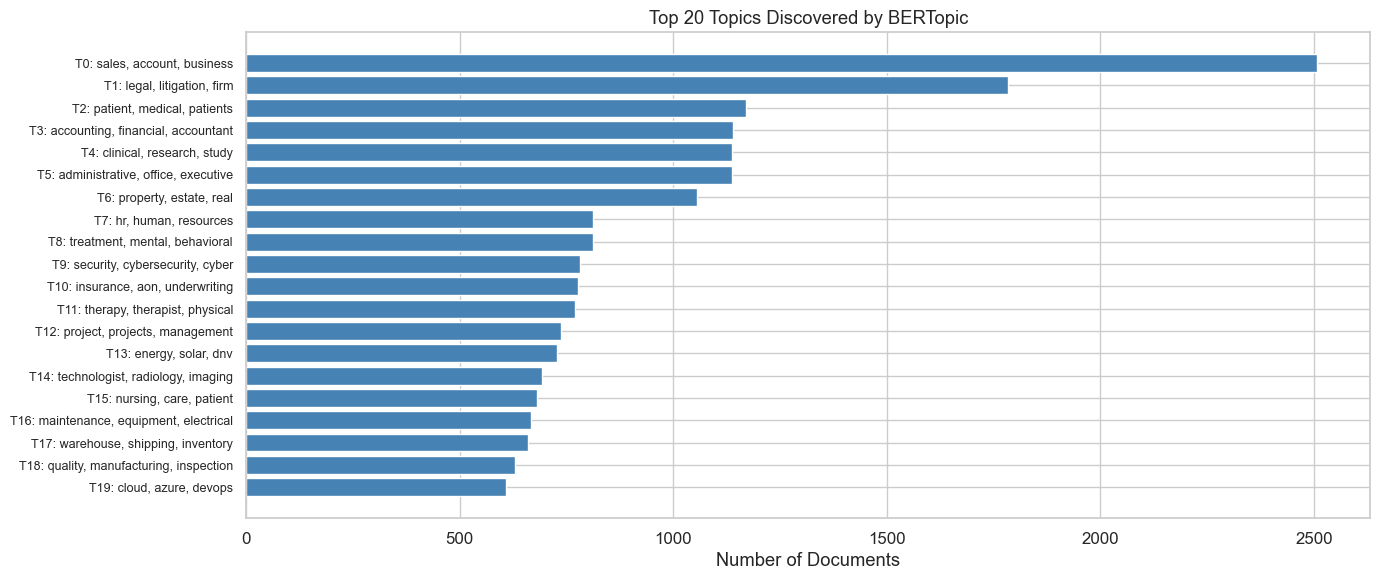

In [8]:
# Visualize topic distribution
fig, ax = plt.subplots(figsize=(14, 6))

# Count documents per topic (excluding outliers)
topic_counts = pd.Series(topics)
topic_counts_no_outlier = topic_counts[topic_counts != -1].value_counts().head(20)

topic_labels = []
for t in topic_counts_no_outlier.index:
    top_words = topic_model.get_topic(t)
    label = f"T{t}: {', '.join([w for w, _ in top_words[:3]])}"
    topic_labels.append(label)

ax.barh(range(len(topic_labels)), topic_counts_no_outlier.values, color='steelblue')
ax.set_yticks(range(len(topic_labels)))
ax.set_yticklabels(topic_labels, fontsize=9)
ax.set_xlabel('Number of Documents')
ax.set_title('Top 20 Topics Discovered by BERTopic')
ax.invert_yaxis()

plt.tight_layout()
save_fig(fig, 'nlp_bertopic_top_topics')
plt.show()

### Interpretation

- Each topic is a **natural cluster** of job descriptions with similar content
- The top words are the most distinctive terms for that cluster (via c-TF-IDF with English stopwords removed)
- **Outlier topic (-1)**: Documents that don't fit neatly into any cluster. With HDBSCAN, 30-50% outliers is normal for heterogeneous datasets like job postings — many jobs are unique or don't cluster well
- Look for recognizable job families: software engineering, healthcare, sales, marketing, legal, etc.
- This is **unsupervised** — no manual labels needed! The algorithm found these groupings from the text alone

**For Phase 4 (RAG)**: Topic labels can help organize search results — "Your query matches Topic 5 (AI & machine learning)."

In [9]:
# Add topic assignments to the dataframe
df['topic_id'] = topics

# Cross-reference: topics vs experience level
print("Topic distribution across experience levels (top 10 topics):")
print("=" * 60)

top_10_topics = topic_counts_no_outlier.head(10).index.tolist()
df_topics = df[df['topic_id'].isin(top_10_topics)]

cross_tab = pd.crosstab(
    df_topics['topic_id'],
    df_topics['experience_level'],
    normalize='index'
).round(3) * 100

print(cross_tab.to_string())

Topic distribution across experience levels (top 10 topics):
experience_level  Associate  Director  Entry level  Executive  Internship  Mid-Senior level  Unknown
topic_id                                                                                            
0                      13.5       7.4         14.4        2.3         0.3              31.5     30.5
1                      22.9       1.7         15.9        0.7         0.5              26.7     31.6
2                       4.9       3.1         42.6        1.0         0.3              19.8     28.2
3                      14.3       8.6         11.8        1.8         0.4              42.6     20.6
4                       8.3      11.8         15.2        2.3         0.5              37.3     24.6
5                      18.1       1.2         26.6        1.2         0.2              22.3     30.3
6                       9.7       4.5         17.7        2.3         1.4              38.3     26.1
7                      14.5   

## 4. Save BERTopic Model

In [10]:
# Save the BERTopic model for later use (RAG, Streamlit app)
if not FORCE_RECOMPUTE and BERTOPIC_MODEL_DIR.exists() and any(BERTOPIC_MODEL_DIR.iterdir()):
    print(f"BERTopic model already saved at {BERTOPIC_MODEL_DIR}")
else:
    BERTOPIC_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    topic_model.save(str(BERTOPIC_MODEL_DIR), serialization='safetensors', save_ctfidf=True)
    print(f"BERTopic model saved to {BERTOPIC_MODEL_DIR}")

# Always save topic assignments (cheap operation)
df[['job_id', 'topic_id']].to_parquet(PROCESSED_DIR / 'topic_assignments.parquet', index=False)
print(f"Topic assignments saved to {PROCESSED_DIR / 'topic_assignments.parquet'}")

BERTopic model saved to D:\GigaDocuments\projects\TalentLens\models\bertopic_model
Topic assignments saved to D:\GigaDocuments\projects\TalentLens\data\processed\topic_assignments.parquet


## 5. Embedding Space Visualization (2D)

Let's project the 384-dim embeddings down to 2D using UMAP so we can visualize the clusters.

In [11]:
# Use a sample for 2D visualization (full dataset would take too long)
SAMPLE_SIZE = 10000
np.random.seed(42)
sample_idx = np.random.choice(len(embeddings), size=min(SAMPLE_SIZE, len(embeddings)), replace=False)

sample_embeddings = embeddings[sample_idx]
sample_topics = np.array(topics)[sample_idx]
sample_exp = df.iloc[sample_idx]['experience_level'].values

# UMAP to 2D for visualization
from umap import UMAP
umap_2d = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
coords_2d = umap_2d.fit_transform(sample_embeddings)

print(f"Projected {len(sample_embeddings):,} embeddings to 2D")

Projected 10,000 embeddings to 2D


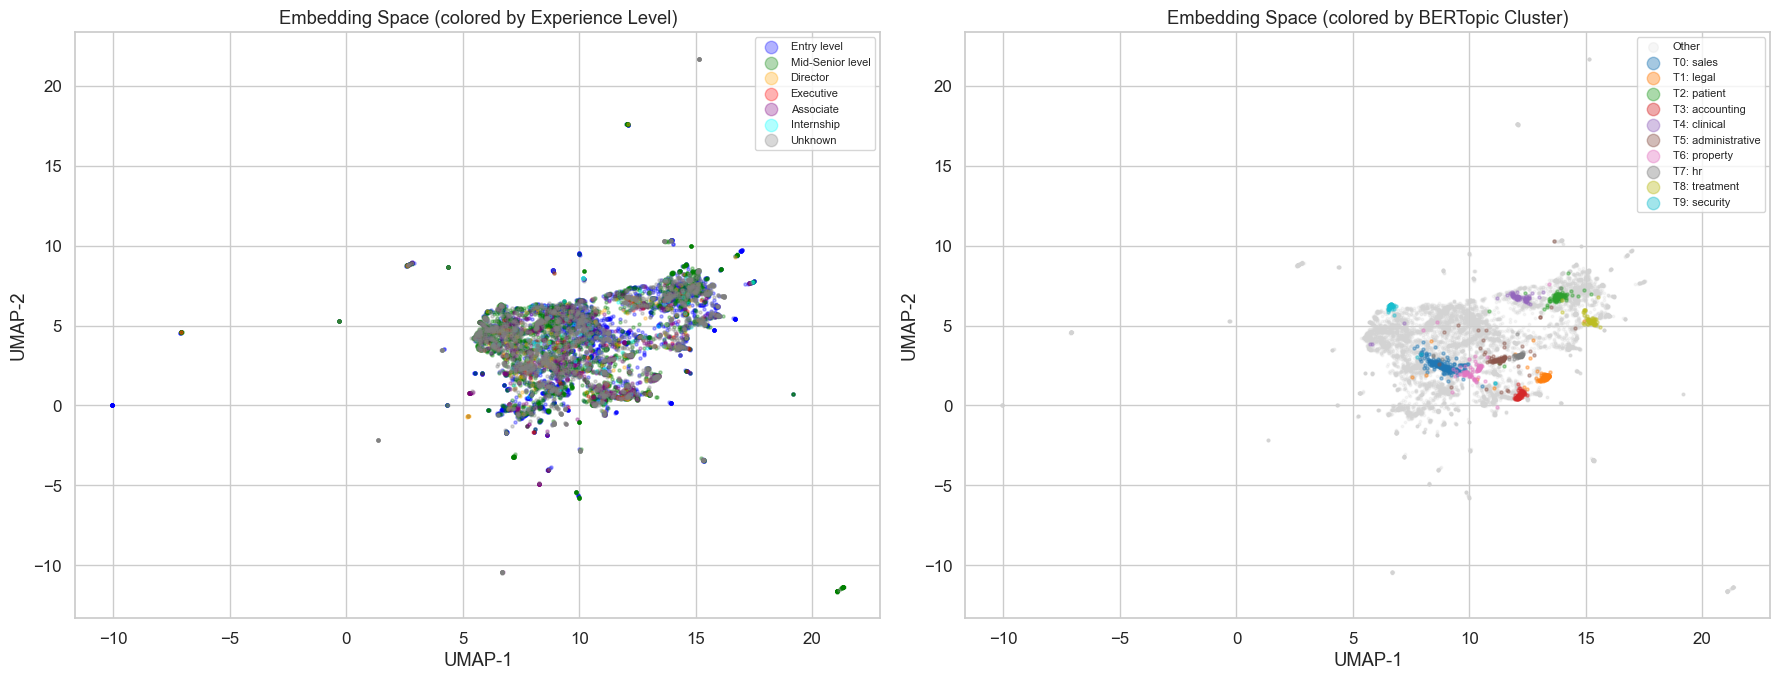

In [12]:
# Plot: Color by experience level
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# By experience level
exp_colors = {'Entry level': 'blue', 'Mid-Senior level': 'green', 'Director': 'orange',
              'Executive': 'red', 'Associate': 'purple', 'Internship': 'cyan', 'Unknown': 'gray'}

for level, color in exp_colors.items():
    mask = sample_exp == level
    if mask.sum() > 0:
        axes[0].scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                       c=color, label=level, alpha=0.3, s=5)
axes[0].set_title('Embedding Space (colored by Experience Level)')
axes[0].legend(markerscale=4, fontsize=8)
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')

# By topic (top 10 topics only, rest in gray)
top_topics_set = set(top_10_topics)
cmap = plt.cm.tab10

# Plot outliers/other topics in gray first
other_mask = ~np.isin(sample_topics, list(top_topics_set))
axes[1].scatter(coords_2d[other_mask, 0], coords_2d[other_mask, 1],
               c='lightgray', alpha=0.2, s=3, label='Other')

for i, topic_id in enumerate(top_10_topics):
    mask = sample_topics == topic_id
    if mask.sum() > 0:
        top_words = topic_model.get_topic(topic_id)
        label = f"T{topic_id}: {top_words[0][0]}"
        axes[1].scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                       c=[cmap(i)], label=label, alpha=0.4, s=5)

axes[1].set_title('Embedding Space (colored by BERTopic Cluster)')
axes[1].legend(markerscale=4, fontsize=8, loc='upper right')
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')

plt.tight_layout()
save_fig(fig, 'nlp_embedding_space_2d')
plt.show()

### How to read the UMAP plots

- Each **dot** is one job posting, projected from 384 dimensions down to 2
- **Close dots** = similar job descriptions (in embedding space)
- **Left plot** (experience level): Do experience levels form distinct clusters, or are they mixed? If mixed, that means description content doesn't perfectly separate by seniority level — the text is more about the role type (engineering, sales, etc.) than the level.
- **Right plot** (topics): BERTopic clusters should show cleaner separation — each cluster is a coherent group of similar jobs
- **Gray dots** = outliers or topics not in the top 10

**Key insight**: The embedding space captures **semantic similarity**, not just keyword overlap. Jobs that describe similar work end up close together, even if they use different words.

## Summary

### What we built
1. **Embeddings**: 384-dim dense vectors for every job description using `all-MiniLM-L6-v2`
2. **Nearest neighbor search**: Verified that similar jobs have similar embeddings
3. **BERTopic**: Discovered natural topic clusters without manual labels
4. **2D visualization**: Projected embedding space to see cluster structure

### Mental model: The embedding pipeline

```
desc_clean (text) → SentenceTransformer → 384-dim embedding → .npy file
                                              ↓
                                         BERTopic (UMAP → HDBSCAN → c-TF-IDF)
                                              ↓
                                         Topic assignments → .parquet file
```

### Files created
| File | What it contains |
|------|------------------|
| `data/processed/description_embeddings.npy` | 123K × 384 float32 array |
| `data/processed/embedding_job_ids.npy` | Parallel array of job IDs |
| `data/processed/topic_assignments.parquet` | job_id → topic_id mapping |
| `models/bertopic_model/` | Saved BERTopic model (reloadable) |

### Key decisions
- **Embed desc_clean, not desc_lemmatized**: The transformer model handles its own tokenization
- **all-MiniLM-L6-v2**: Fast, free, 384-dim — good balance of quality and speed
- **BERTopic over LDA**: BERTopic uses embeddings (semantic), LDA uses word counts (lexical)
- **min_cluster_size=100**: Avoids tiny noise clusters, keeps topics meaningful

### What comes next
- **Phase 3**: ML models using these features (salary prediction, ghost job detection)
- **Phase 4**: FAISS index built from these embeddings → RAG pipeline with LangChain + Ollama

---

**→ Next**: Phase 3 — ML Models (salary prediction, ghost job classification, statistical tests)